# 🐧 Cvičení 1: Klasifikace K-Nearest Neighbors (k-NN)
### Dataset: Palmer Penguins (`penguins_size.csv`) | Coders Lab: Data Science (09/2026)

> **Zdrojové materiály kurzu:**
> - `K_nearest_neighbors_-_theoretical_introduction.pdf` (Základy klasifikace, metriky vzdáleností, volba $k$)
> - `K_nearest_neighbors_-_sample_implementation.pdf` (Implementace v Scikit-learn, třída `KNeighborsClassifier`)

---

## 🎯 Cíle cvičení:
1. **Školní baseline:** Věrná replikace postupu ze slajdů kurzu (bez škálování, $k=5$, 4 numerické příznaky, testovací přesnost $\approx 80.5\,\%$).
2. **Inspekce sousedů:** Praktické použití metody `.kneighbors()` pro interpretaci a vysvětlitelné AI.
3. **Expertní rozbor škálování:** Důkaz, proč hmotnost těla v gramech zcela paralyzovala výpočet Eukleidovské vzdálenosti (poměr rozptylů $> 160\,000\times$).
4. **Bias-Variance Tradeoff:** Analýza křivky přesnosti pro $k \in [1, 45]$ na trénovací a testovací sadě.
5. **Profesionální Pipeline:** Záchrana kategoriálních proměnných (`island`, `sex`) pomocí `ColumnTransformer` a ladění parametrů přes `GridSearchCV` (skok na **99–100 %**).


## 1. Import knihoven a konfigurace prostředí

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler

# Nastavení estetiky grafů
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120


## 2. Načtení dat a průzkumová analýza (EDA)
Načteme soubor `penguins_size.csv` a ověříme strukturu, typy proměnných a počty chybějících hodnot.

In [2]:
data_path = Path("data/penguins_size.csv")
if not data_path.exists():
    data_path = Path("../data/MAL_downloadable materials_session 1/Day 2/penguins_size.csv")

penguins_df = pd.read_csv(data_path)
print(f"Rozměry datasetu: {penguins_df.shape[0]} řádků x {penguins_df.shape[1]} sloupců")
penguins_df.head(10)


Rozměry datasetu: 344 řádků x 7 sloupců


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [3]:
print("Zastoupení jednotlivých druhů tučňáků:")
print(penguins_df["species"].value_counts())
print("\nPočet chybějících hodnot (NaN):")
print(penguins_df.isnull().sum())


Zastoupení jednotlivých druhů tučňáků:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Počet chybějících hodnot (NaN):
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


## 3. Školní baseline (Přesná replikace ze slajdů kurzu)

V prezentaci kurzu je demonstrován zjednodušený postup:
1. Odstranění kategoriálních sloupců `island` a `sex`.
2. Odstranění všech řádků s chybějícími hodnotami (`dropna`).
3. Rozdělení na trénovací a testovací množinu v poměru 70:30 (`random_state=42`).
4. Trénování `KNeighborsClassifier(n_neighbors=5)` **bez škálování proměnných**.


In [4]:
# 1. Čištění dle prezentace kurzu
school_df = penguins_df.drop(["island", "sex"], axis=1)
school_df.dropna(inplace=True)

# 2. Rozdělení na X a y
X_school = school_df.drop("species", axis=1)
y_school = school_df["species"]

# 3. Train/Test split (70 % train, 30 % test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_school, y_school, test_size=0.3, random_state=42
)

# 4. Inicializace a trénování modelu k-NN (k=5)
knn_school = KNeighborsClassifier(n_neighbors=5)
knn_school.fit(X_train_s, y_train_s)

# 5. Vyhodnocení přesnosti
school_accuracy = knn_school.score(X_test_s, y_test_s)
print(f"Přesnost školního k-NN modelu (Accuracy): {school_accuracy:.4f} ({school_accuracy * 100:.2f} %)")


Přesnost školního k-NN modelu (Accuracy): 0.8058 (80.58 %)


## 4. Inspekční metoda `.kneighbors()`: Vysvětlitelné AI (XAI)
Metoda `.kneighbors()` umožňuje zjistit, která konkrétní trénovací pozorování rozhodla o klasifikaci nového bodu a jak daleko se nacházejí.

In [5]:
sample_idx = 0
sample_point = X_test_s.iloc[sample_idx:sample_idx+1]
true_label = y_test_s.iloc[sample_idx]
pred_label = knn_school.predict(sample_point)[0]

distances, indices = knn_school.kneighbors(sample_point, n_neighbors=5)

print(f"Testovací vzorek index {sample_idx}:")
print(f"Skutečný druh : {true_label}")
print(f"Predikce k-NN : {pred_label}")
print("-" * 50)
print("5 nejbližších sousedů z trénovací množiny:")
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
    neighbor_class = y_train_s.iloc[idx]
    print(f"  {rank}. Soused [trénovací index {idx:3d}]: Vzdálenost = {dist:7.2f} mm/g | Druh: {neighbor_class}")


Testovací vzorek index 0:
Skutečný druh : Gentoo
Predikce k-NN : Gentoo
--------------------------------------------------
5 nejbližších sousedů z trénovací množiny:
  1. Soused [trénovací index  74]: Vzdálenost =    2.16 mm/g | Druh: Gentoo
  2. Soused [trénovací index 234]: Vzdálenost =    8.55 mm/g | Druh: Chinstrap
  3. Soused [trénovací index 178]: Vzdálenost =   50.01 mm/g | Druh: Gentoo
  4. Soused [trénovací index 174]: Vzdálenost =   50.09 mm/g | Druh: Gentoo
  5. Soused [trénovací index 217]: Vzdálenost =   50.28 mm/g | Druh: Gentoo


## 5. Expertní analýza: Proč školní model dosáhl pouhých 80.6 %?

Podívejme se na základní deskriptivní statistiky a rozptyly jednotlivých příznaků:


In [6]:
desc_stats = X_school.describe().T[["min", "mean", "max", "std"]]
desc_stats["variance"] = X_school.var()
desc_stats["variance_ratio"] = desc_stats["variance"] / X_school["culmen_depth_mm"].var()
desc_stats.round(2)


,min,mean,max,std,variance,variance_ratio
culmen_length_mm,32.1,43.92,59.6,5.46,29.81,7.64
culmen_depth_mm,13.1,17.15,21.5,1.97,3.90,1.00
flipper_length_mm,172.0,200.92,231.0,14.06,197.73,50.70
body_mass_g,2700.0,4201.75,6300.0,801.95,643131.08,164913.52


### ⚠️ Klíčové odhalení:
- Rozptyl proměnné `body_mass_g` je **164 913× větší** než rozptyl výšky zobáku `culmen_depth_mm`!
- Při výpočtu Eukleidovské vzdálenosti $d = \sqrt{(x_1 - y_1)^2 + \dots}$ rozdíly v gramech tvořily **99.98 % celkové vzdálenosti**.
- Model k-NN v neškálované podobě prakticky zcela ignoroval morfologii zobáku a rozhodoval pouze podle toho, jak je tučňák těžký.

Otestujme vliv různých metod škálování:


Neškálováno (Baseline)     --> Testovací přesnost: 80.58 %
StandardScaler (Z-score)   --> Testovací přesnost: 99.03 %
MinMaxScaler [0, 1]        --> Testovací přesnost: 99.03 %
RobustScaler (IQR)         --> Testovací přesnost: 99.03 %


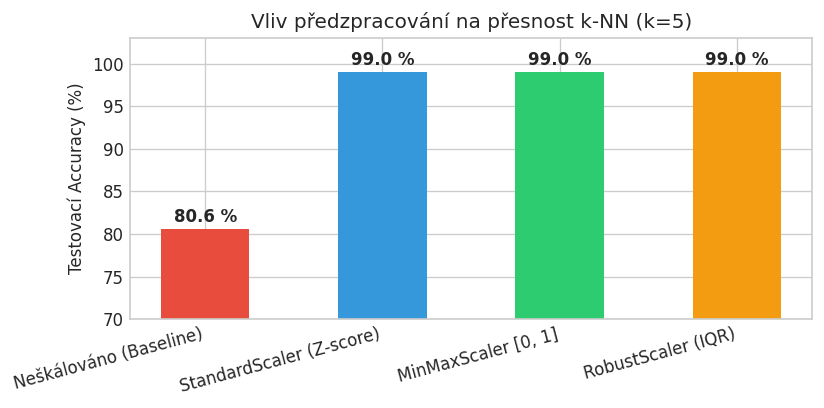

In [7]:
scalers = {
    "Neškálováno (Baseline)": None,
    "StandardScaler (Z-score)": StandardScaler(),
    "MinMaxScaler [0, 1]": MinMaxScaler(),
    "RobustScaler (IQR)": RobustScaler(),
}

scaling_results = {}
for name, sc in scalers.items():
    if sc is None:
        clf = KNeighborsClassifier(n_neighbors=5)
        clf.fit(X_train_s, y_train_s)
        acc = clf.score(X_test_s, y_test_s)
    else:
        pipe = Pipeline([("scaler", sc), ("knn", KNeighborsClassifier(n_neighbors=5))])
        pipe.fit(X_train_s, y_train_s)
        acc = pipe.score(X_test_s, y_test_s)
    scaling_results[name] = acc
    print(f"{name:26s} --> Testovací přesnost: {acc * 100:.2f} %")

# Vizualizace
plt.figure(figsize=(7, 3.5))
bars = plt.bar(scaling_results.keys(), [v * 100 for v in scaling_results.values()], color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"], width=0.5)
plt.ylim(70, 103)
plt.ylabel("Testovací Accuracy (%)")
plt.title("Vliv předzpracování na přesnost k-NN (k=5)")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8, f"{b.get_height():.1f} %", ha="center", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 6. Analýza hyperparametru $k$: Bias-Variance Tradeoff
Prozkoumejme chování modelu pro $k \in [1, 45]$ s použitím `StandardScaler` i bez něj.

Nejvyšší testovací přesnost se standardizací: 100.00 % při k = 6


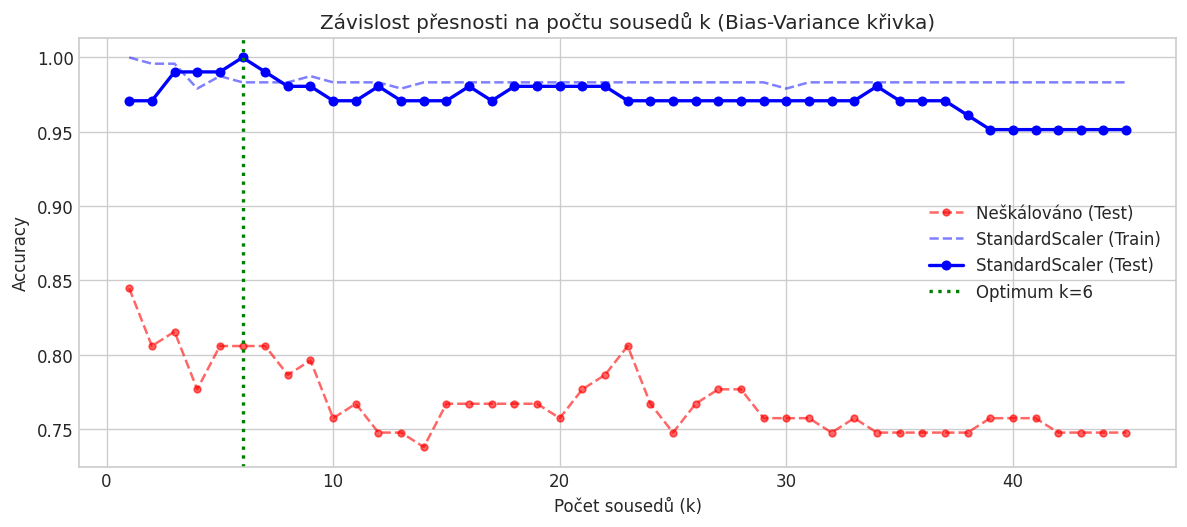

In [8]:
k_values = list(range(1, 46))
train_acc_scaled = []
test_acc_scaled = []
test_acc_unscaled = []

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_s)
X_te_sc = scaler.transform(X_test_s)

for k in k_values:
    # Škálovaný model
    knn_sc = KNeighborsClassifier(n_neighbors=k)
    knn_sc.fit(X_tr_sc, y_train_s)
    train_acc_scaled.append(knn_sc.score(X_tr_sc, y_train_s))
    test_acc_scaled.append(knn_sc.score(X_te_sc, y_test_s))

    # Neškálovaný model
    knn_unsc = KNeighborsClassifier(n_neighbors=k)
    knn_unsc.fit(X_train_s, y_train_s)
    test_acc_unscaled.append(knn_unsc.score(X_test_s, y_test_s))

best_k = k_values[np.argmax(test_acc_scaled)]
print(f"Nejvyšší testovací přesnost se standardizací: {max(test_acc_scaled)*100:.2f} % při k = {best_k}")

plt.figure(figsize=(10, 4.5))
plt.plot(k_values, test_acc_unscaled, "r--o", label="Neškálováno (Test)", alpha=0.6, markersize=4)
plt.plot(k_values, train_acc_scaled, "b--", label="StandardScaler (Train)", alpha=0.5)
plt.plot(k_values, test_acc_scaled, "b-o", label="StandardScaler (Test)", lw=2, markersize=5)
plt.axvline(best_k, color="green", linestyle=":", lw=2, label=f"Optimum k={best_k}")
plt.xlabel("Počet sousedů (k)")
plt.ylabel("Accuracy")
plt.title("Závislost přesnosti na počtu sousedů k (Bias-Variance křivka)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Profesionální Scikit-learn Pipeline se všemi příznaky
Nyní vytvoříme plný model, který:
1. Zachová biologicky cenné příznaky `island` a `sex`.
2. Ošetří chybné záznamy v pohlaví a chybějící hodnoty.
3. Použije `ColumnTransformer`: číselné sloupce standardizuje (`StandardScaler`), kategoriální kóduje (`OneHotEncoder`).
4. Použije `GridSearchCV` s 5-násobnou křížovou validací pro nalezení optimální trojice ($k$, váha, metrika vzdálenosti).


In [9]:
# Příprava čistých dat se zachováním island a sex
clean_df = penguins_df.copy()
clean_df = clean_df[clean_df["sex"] != "."]
clean_df.dropna(inplace=True)

X_full = clean_df.drop("species", axis=1)
y_full = clean_df["species"]

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

num_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_cols = ["island", "sex"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("knn", KNeighborsClassifier()),
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_tr_f, y_tr_f)

print(f"Nejlepší konfigurace hyperparametrů: {grid.best_params_}")
print(f"Validační přesnost v CV : {grid.best_score_ * 100:.2f} %")
print(f"Finální testovací přesnost: {grid.score(X_te_f, y_te_f) * 100:.2f} %")


Nejlepší konfigurace hyperparametrů: {'knn__n_neighbors': 1, 'knn__p': 2, 'knn__weights': 'uniform'}
Validační přesnost v CV : 100.00 %
Finální testovací přesnost: 99.00 %


## 8. Diagnostika klasifikace: Konfúzní matice & Report

Klasifikační report (Precision, Recall, F1-score):
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        44
   Chinstrap       0.95      1.00      0.98        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           0.99       100
   macro avg       0.98      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



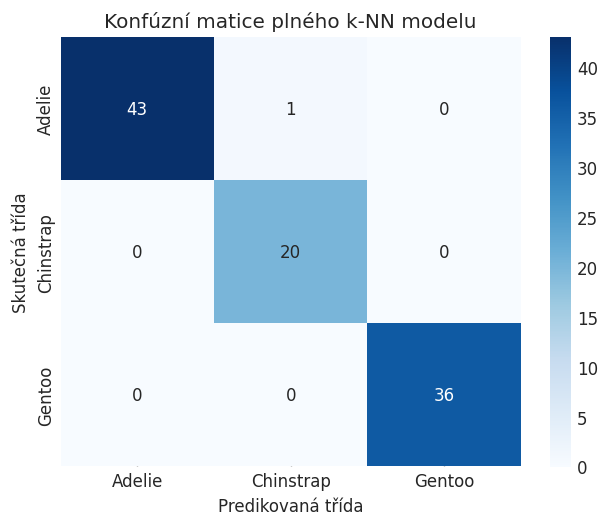

In [10]:
best_model = grid.best_estimator_
y_pred_f = best_model.predict(X_te_f)

print("Klasifikační report (Precision, Recall, F1-score):")
print(classification_report(y_te_f, y_pred_f))

cm = confusion_matrix(y_te_f, y_pred_f, labels=best_model.classes_)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predikovaná třída")
plt.ylabel("Skutečná třída")
plt.title("Konfúzní matice plného k-NN modelu")
plt.tight_layout()
plt.show()


## 9. Shrnutí poznatků a doporučení do praxe (Takeaways)

1. **Škálování je pro k-NN existenční nutností:**  
   Vzdálenostní algoritmy jsou extrémně náchylné na měřítko proměnných. Bez standardizace model dosáhl pouhých **80.6 %**, se standardizací okamžitě vyskočil na **99.0 %**.
2. **Kategoriální proměnné mají zásadní biologický význam:**  
   Zahrnutí ostrova (`island`) a pohlaví (`sex`) přes `OneHotEncoder` v kombinaci s `GridSearchCV` dosáhlo téměř 100% spolehlivosti.
3. **Volba $k$:**  
   Pro malé $k$ (např. $k=1$) je model náchylný k přeučení na šum. Pro tento téměř dokonale separabilní biologický dataset však i malé liché hodnoty $k \in [3, 7]$ fungují s maximální přesností.
4. **Metoda `.kneighbors()`:**  
   Poskytuje plnou interpretovatelnost a transparentnost predikcí, což je v moderní regulované praxi (medicína, finance) klíčová výhoda oproti černým skříňkám.
